In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf 


#Regression

In [3]:
#Load dataset (50 samples)
x = np.random.rand(50)
y = 2 * x + 1 + np.random.randn(50) * 0.1

#Convert 1D array to 2D
x = np.expand_dims(x, axis=1)
y = np.expand_dims(y, axis=1)

print(f"The shape of the input x is : {x.shape}")
print(f"The shape of the input y is : {y.shape}")


The shape of the input x is : (50, 1)
The shape of the input y is : (50, 1)


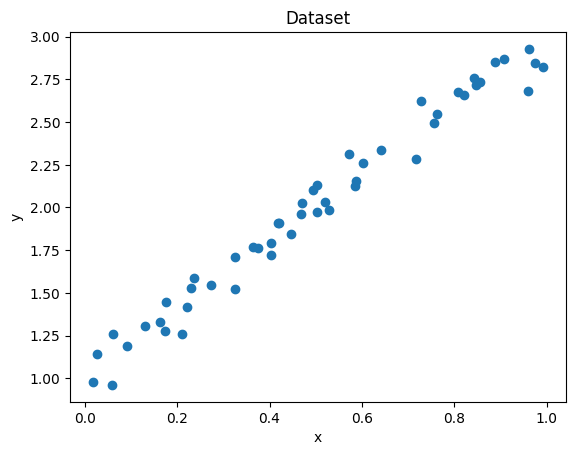

In [4]:
#plot the dataset
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset")
plt.show()

In [5]:
#Split the dataset 
#Get 60% of dataset as the traiing set, Put the remaining 0% in temorary in temporary variables.

x_train,x_, y_train, y_ = train_test_split(x,y, test_size=0.40, random_state=1)

#Split the 40% subset into two: one half for cross validation and other for testing
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

#Delete temporary variables
del x_, y_

print(f"Shape of training set (input) is:{x_train.shape}") 
print(f"Shape of training set (target) is:{y_train.shape}")
print(f"Shape of cross validation set (input) is:{x_cv.shape}")
print(f"Shape of cross validation set (target) is:{y_cv.shape}")
print(f"Shape of test set (input) is:{x_test.shape}")
print(f"Shape of test set (target) is:{y_test.shape}")

Shape of training set (input) is:(30, 1)
Shape of training set (target) is:(30, 1)
Shape of cross validation set (input) is:(10, 1)
Shape of cross validation set (target) is:(10, 1)
Shape of test set (input) is:(10, 1)
Shape of test set (target) is:(10, 1)


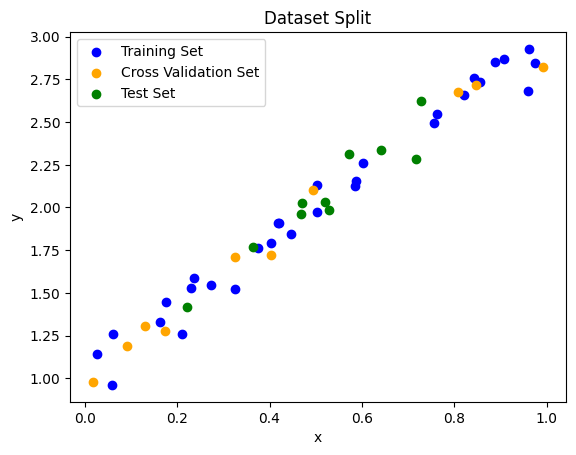

In [6]:
#Plot the training set, cross validation set and test set
plt.scatter(x_train, y_train, color='blue', label='Training Set')
plt.scatter(x_cv, y_cv, color='orange', label='Cross Validation Set')
plt.scatter(x_test, y_test, color='green', label='Test Set')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Dataset Split')
plt.legend()
plt.show()

Compute mean of the training set: 0.51
Compute standard deviatio  of the training set:0.30


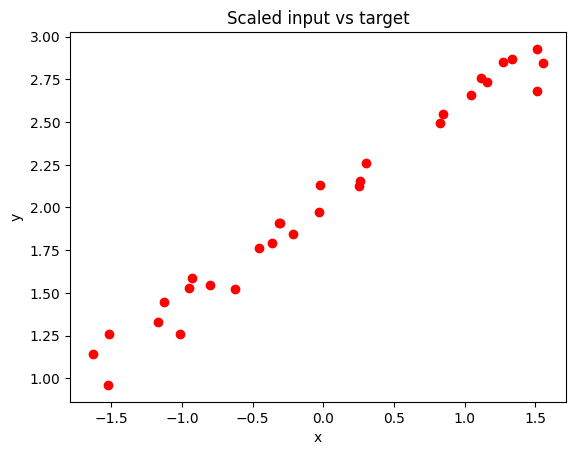

In [7]:
#Initialize the class
scaler_linear = StandardScaler()

#Compute the mean and standard deviation of training set then transform it
x_train_sclaed = scaler_linear.fit_transform(x_train)

print(f"Compute mean of the training set: {scaler_linear.mean_.squeeze():.2f}")
print(f"Compute standard deviatio  of the training set:{scaler_linear.scale_.squeeze():.2f}")

#Plot the results
plt.scatter(x_train_sclaed, y_train, color='red')
plt.xlabel("x")
plt.ylabel('y')
plt.title("Scaled input vs target")
plt.show()


In [8]:
#Train the model
linear_model = LinearRegression()

linear_model.fit(x_train_sclaed, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
#Evaluate model
yhat = linear_model.predict(x_train_sclaed)

print(f"Training MSE(using sklearn function): {mean_squared_error(y_train, yhat)/2}")

total_squared_error = 0

for i in range(len(yhat)):
    squared_error_i = (yhat[i] - y_train[i])**2
    total_squared_error += squared_error_i
    
mse = total_squared_error / (2*len(yhat))
print(f"training MSE (for loop implementation):{mse.squeeze()}")    

Training MSE(using sklearn function): 0.0038727652666821722
training MSE (for loop implementation):0.0038727652666821727


In [10]:
#Scale the cross validation set using the mean and standard deviation of the training set
x_cv_scaled = scaler_linear.transform(x_cv)

print(f"Mean used to sclae the cv set:{scaler_linear.mean_.squeeze():.2f}")
print(f"Standar deviation used to sclae the cv set:{scaler_linear.scale_.squeeze():.2f}")

#Feed scaled cross validation set
yhat = linear_model.predict(x_cv_scaled)

#Mean squared error
print(f"Cross validation MSE: {mean_squared_error(y_cv, yhat)/2}")

Mean used to sclae the cv set:0.51
Standar deviation used to sclae the cv set:0.30
Cross validation MSE: 0.0032928704652520546


In [11]:
#Adding polynomial features

poly = PolynomialFeatures(degree=2, include_bias=False)

x_train_mapped = poly.fit_transform(x_train)

print(x_train_mapped[:5])

[[0.82048649 0.67319807]
 [0.44704055 0.19984525]
 [0.96045243 0.92246888]
 [0.40353676 0.16284192]
 [0.90758895 0.8237177 ]]


In [12]:
#Instantiate the class
scaler_poly = StandardScaler()

x_train_mapped_sclaed = scaler_poly.fit_transform(x_train_mapped)

print(x_train_mapped_sclaed[:5])

[[ 1.04188747  1.01316646]
 [-0.21561756 -0.46790893]
 [ 1.513195    1.79311081]
 [-0.36210794 -0.5836888 ]
 [ 1.33518771  1.48412788]]


In [13]:
#Initialize the class
model = LinearRegression()

#Train
model.fit(x_train_mapped_sclaed, y_train)

#compute mse
yhat = model.predict(x_train_mapped_sclaed)
print(f"Training MSE:{mean_squared_error(y_train, yhat)/2}")

#Add polynomial features to cross validation
x_cv_mapped = poly.transform(x_cv)

#Scale cross validai=tion set using mean & std of training set
x_cv_mapped_scaled = scaler_poly.transform(x_cv_mapped)

#Compute cross validation mse
yhat = model.predict(x_cv_mapped_scaled)
print(f"Cross Validation MSE:{mean_squared_error(y_cv,yhat)/2}")

Training MSE:0.0038226021563374135
Cross Validation MSE:0.002800583579639449


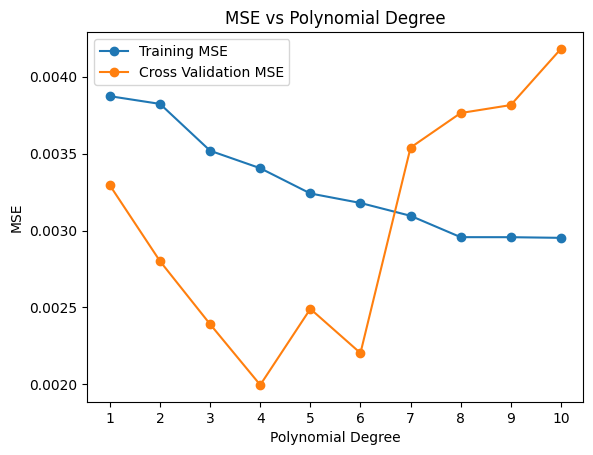

In [14]:
#Initialize lists to save errors, models, and features transforms
train_mses = []
cv_mses = []
models = []
polys = []
scalers = []

#loop over polynomial degrees from 1 to 10
for degree in range(1,11):
    #Add polynomial features to training set
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    x_train_mapped = poly.fit_transform(x_train)
    polys.append(poly)
    
    #Scale the training set
    scaler = StandardScaler()
    x_train_mapped_scaled = scaler.fit_transform(x_train_mapped)
    scalers.append(scaler)

    
    #Train the model
    model = LinearRegression()
    model.fit(x_train_mapped_scaled, y_train)
    models.append(model)
    
    #Compute training MSE
    yhat_train = model.predict(x_train_mapped_scaled)
    train_mse = mean_squared_error(y_train, yhat_train)/2
    train_mses.append(train_mse)
    
    #Add polynomial features to cross validation set
    x_cv_mapped = poly.transform(x_cv)
    x_cv_mapped_scaled = scaler.transform(x_cv_mapped)
     
    #Compute cross validation MSE
    yhat_cv = model.predict(x_cv_mapped_scaled)
    cv_mse = mean_squared_error(y_cv, yhat_cv)/2
    cv_mses.append(cv_mse)
    
#Plot training and cross validation MSE vs polynomial degree
plt.plot(range(1,11), train_mses, marker='o', label='Training MSE')
plt.plot(range(1,11), cv_mses, marker='o', label='Cross Validation MSE')
plt.xlabel('Polynomial Degree') 
plt.ylabel('MSE')
plt.title('MSE vs Polynomial Degree')
plt.xticks(range(1,11))
plt.legend()
plt.show()

In [15]:
degree = np.argmin(cv_mses) + 1
print(f"Optimal polynomial degree: {degree}")

Optimal polynomial degree: 4


In [16]:
#Add polynomial features to test set using the optimal degree
optimal_poly = polys[degree-1].transform(x_test)

x_test_mapped_scaled = scalers[degree-1].transform(optimal_poly)

yhat = models[degree-1].predict(x_test_mapped_scaled)

print(f"Training MSE: {train_mses[degree-1]}")
print(f"Cross Validation MSE: {cv_mses[degree-1]}")
print(f"Test MSE: {mean_squared_error(y_test, yhat)/2}")


Training MSE: 0.0034048151843584693
Cross Validation MSE: 0.001996973055628192
Test MSE: 0.004771120682815595


#Neural Networks